# 1. Загрузка данных и первичный анализ

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, RocCurveDisplay, confusion_matrix
from sklearn.metrics._plot.confusion_matrix import ConfusionMatrixDisplay

df = pd.read_csv('./S06-hw-dataset-01.csv')
x = df.drop(['id', 'target'], axis=1)
y = df['target'] # Target

display(df.head())
display(df.info())
display(df.describe())

print("\nНулевые значения")
display(df.isna())

print("\nТипы (dtypes) значений столбцов/колонок")
print(df.dtypes)

print("\nДоля/соотношение таргет классов")
display(y.value_counts(normalize=True).to_frame()) # Явно виден дисбаланс классов

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

None

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000



Нулевые значения


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Типы (dtypes) значений столбцов/колонок
id                 int64
num01            float64
num02            float64
num03            float64
num04            float64
num05            float64
num06            float64
num07            float64
num08            float64
num09            float64
num10            float64
num11            float64
num12            float64
num13            float64
num14            float64
num15            float64
num16            float64
num17            float64
num18            float64
num19            float64
num20            float64
num21            float64
num22            float64
num23            float64
num24            float64
cat_contract       int64
cat_region         int64
cat_payment        int64
tenure_months      int64
target             int64
dtype: object

Доля/соотношение таргет классов


,proportion
target,
0,0.676583
1,0.323417


# 2. Train/Test-сплит и воспроизводимость

In [2]:
rs = 42 # Random state. Вопспроизводимость
cv = StratifiedKFold(n_splits=2, random_state=rs, shuffle=True)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.25,
    random_state = rs, stratify = y
)


 **Фиксированные `random_state` очень важен, в обратном случае при каждом перезапуске скрипта/пайплайна случайным образом будет разделен на train/test подвыборки датасета. Seed же указывает, что разделение происходит по заданному значению. То есть это позволяет повторно вопроизвести обучение и тестовую оценку моделей**

 **Стратификация данных же позволяет сохранить пропорцию классов в соотношении с test_size**

# 3. Baseline’ы
## DummyClassifier

In [3]:
 # Классификатор
dummCls = DummyClassifier(strategy="most_frequent")
## Обучение
dummCls.fit(x_train,y_train)
## Предсказывание
dummCls.predict(x_test)
## Метрики
dummCls.score(x_test,y_test)



0.6766666666666666

In [4]:
# Функция для печати метрик
def print_metrics(model,x_test,y_test,y_pred=None):
    print("Accuracy on test")
    print(model.score(x_test,y_test))
    if y_pred is not None:
        print("F1_score")
        print(f1_score(y_test,y_pred))

        print("ROC-AUC")
        print(roc_auc_score(y_test,y_pred))

## LogisticRegression

In [5]:
# Пайплайн
pipe = Pipeline(
    [("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=rs))
])
pipe.fit(x_train,y_train)
y_pred_logreg = pipe.predict(x_test)
print_metrics(pipe,x_test,y_test,y_pred_logreg)



Accuracy on test
0.829
F1_score
0.7129266927811976
ROC-AUC
0.7840155400944593


Как видим, `DummyClassifier`, `LogisticRegression` предсказали на тестовой выборке не очень. Эти метрики будут служить базовым минимумом при обучении боевых моделей

# 4. Модели недели 6 
## DecisionTreeClassifier

In [6]:
tree = DecisionTreeClassifier(max_depth = 2, min_samples_leaf=2, random_state=rs)
tree.fit(x_train,y_train)
y_pred_tree = tree.predict(x_test)
print_metrics(tree,x_test,y_test,y_pred_tree)

Accuracy on test
0.779
F1_score
0.6594761171032357
ROC-AUC
0.7484155197806104


**Дабы предотвратить переобучение дерева. Установлено произвольное значение гиперпараметров `max_depth`, `min_samples_leaf`. Но видно что метрики даже не превосходят бэйзлайн. Но позже подберем гиперпараметры перебором `GridSearchCV` для максимизации метрики `ROC-AUC`**

## RandomForestClassifier

In [7]:
rndf = RandomForestClassifier(max_features=2,min_samples_leaf=2,random_state=rs)
rndf.fit(x_train,y_train)
y_pred_rndf = rndf.predict(x_test)
print_metrics(rndf, x_test, y_test, y_pred_rndf)

Accuracy on test
0.9176666666666666
F1_score
0.8627015008337966
ROC-AUC
0.8869458128078818


## AdaBoostClassifier

In [8]:
boost = AdaBoostClassifier(random_state=rs)
boost.fit(x_train,y_train)
y_pred_boost = boost.predict(x_test)
print_metrics(boost, x_test, y_test, y_pred_boost)

/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy on test
0.8606666666666667
F1_score
0.7698237885462555
ROC-AUC
0.8241023817987914


In [9]:
tree_best = GridSearchCV(estimator = tree,
                         param_grid={"min_samples_leaf":[3,5,15,20],
                                     "max_depth":[3,5,15,20,25]},
                         scoring='roc_auc',
                         n_jobs=-1, cv=cv)
tree_best.fit(x_train,y_train)
print(tree_best.best_score_)

0.9028473021766353


In [10]:
rndf_best = GridSearchCV(estimator=rndf,
                       param_grid={
                           "max_features":[3,5,10,15,20],
                           "min_samples_leaf":[1,2,3,5,10]
                       },scoring='roc_auc',
                        cv=cv, n_jobs=-1
                       )
rndf_best.fit(x_train,y_train)
print(rndf_best.best_score_)

0.9621189877130516


In [11]:
models = [
    ('dt', tree),
    ('rf', rndf),
    ('adaboost', boost)
]
stack = StackingClassifier(estimators = models,cv=cv, final_estimator = LogisticRegression(random_state=rs)) 
stack.fit(x_train,y_train)
y_pred_stack = stack.predict(x_test)
print_metrics(stack, x_test, y_test, y_pred_stack)

/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy on test
0.9213333333333333
F1_score
0.8763102725366876
ROC-AUC
0.9058046823421868


In [12]:
params = {
    "dt__min_samples_leaf":[15,20],
    "dt__max_depth":[10,15],
    "rf__max_features":[5,15],
    "rf__min_samples_leaf":[5,15],
}
grid = GridSearchCV(estimator = stack, param_grid=params, cv=cv, scoring='roc_auc', n_jobs=-1)
grid.fit(x_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/ensemble/_weight_boos

{'dt__max_depth': 15, 'dt__min_samples_leaf': 15, 'rf__max_features': 5, 'rf__min_samples_leaf': 5}
0.9593549582450968


In [13]:
y_pred_rndf_best = rndf_best.predict(x_test)
print_metrics(rndf_best,x_test,y_test,y_pred_rndf_best)

Accuracy on test
0.9696620283378193
F1_score
0.8902045209903121
ROC-AUC
0.9112640292519426


## StackingClassifier

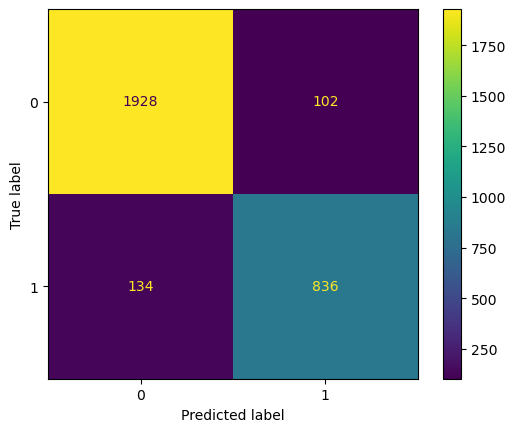

In [14]:
d = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_stack))
d.plot()

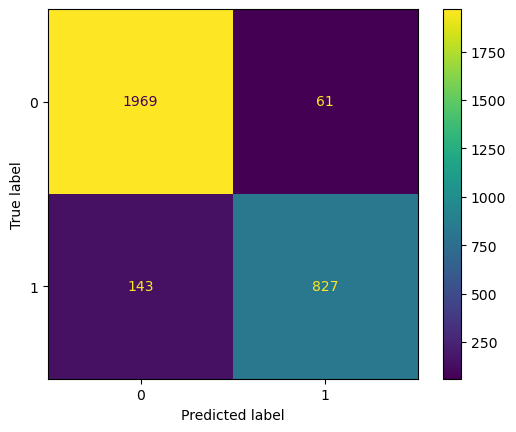

In [15]:
a = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_rndf_best))
a.plot()

# 5. Интерпретация и сохранение артефактов

Calculating Permutation Importance for the best model...


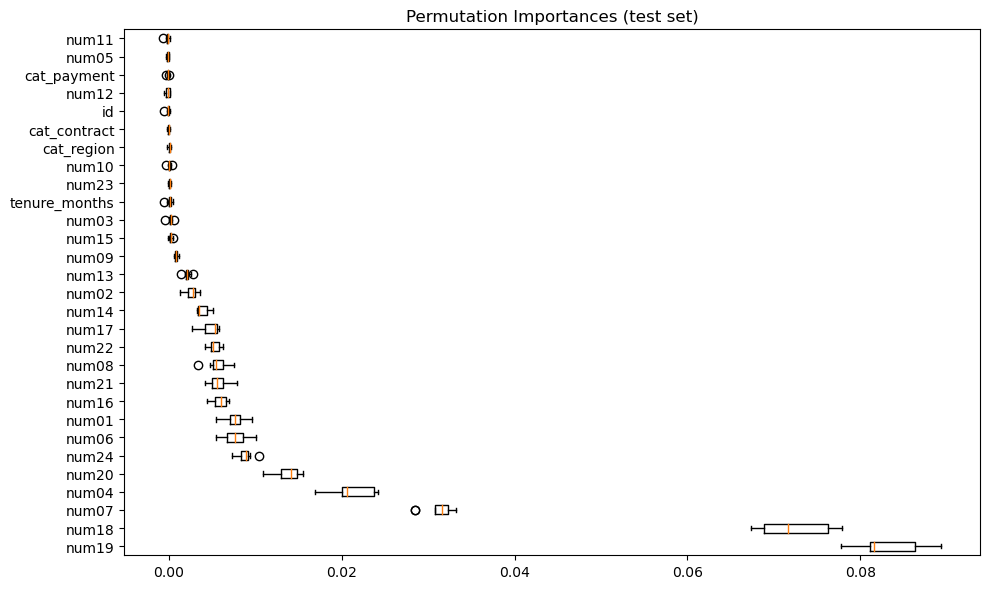

Top 10 features:
num19                0.083 +/- 0.004
num18                0.072 +/- 0.004
num07                0.031 +/- 0.002
num04                0.021 +/- 0.002
num20                0.014 +/- 0.001
num24                0.009 +/- 0.001
num06                0.008 +/- 0.001
num01                0.008 +/- 0.001
num16                0.006 +/- 0.001
num21                0.006 +/- 0.001


In [16]:
# Permutation Importance
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Use the best model found (rndf_best)
best_model = rndf_best 
print("Calculating Permutation Importance for the best model...")
r = permutation_importance(best_model, x_test, y_test,
                           n_repeats=10,
                           random_state=rs,
                           n_jobs=-1)

sorted_idx = r.importances_mean.argsort()[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.boxplot(r.importances[sorted_idx].T,
            vert=False, labels=x_test.columns[sorted_idx])
plt.title("Permutation Importances (test set)")
plt.tight_layout()
# Create directory if not exists (it will be created in the next cell but good to be safe)
import os
os.makedirs('homeworks/HW06/artifacts/figures', exist_ok=True)
plt.savefig('homeworks/HW06/artifacts/figures/permutation_importance.png')
plt.show()

# Print top 10
print("Top 10 features:")
for i in sorted_idx[:10]:
    print(f"{x_test.columns[i]:<20} {r.importances_mean[i]:.3f} +/- {r.importances_std[i]:.3f}")


In [17]:
# Artifacts saving
import json
import os
import joblib

# Ensure artifacts directory exists
os.makedirs('homeworks/HW06/artifacts', exist_ok=True)
os.makedirs('homeworks/HW06/artifacts/figures', exist_ok=True)

# Save confusion matrix for stacking (last plotted)
# We need to recreate the plot to save it if the previous cell didn't save it
# But we can also just plot it again here or save the current figure if it's active.
# Better to explicitly plot and save.

# Confusion Matrix for Best Model (RandomForest)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_rndf_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.savefig('homeworks/HW06/artifacts/figures/confusion_matrix_best.png')
plt.close()

# 1. Metrics on test
# Note: Some models might not be fitted if cells weren't run. 
# We assume the notebook is run sequentially.

metrics = {
    "Dummy": {
        "accuracy": dummCls.score(x_test, y_test),
    },
    "LogisticRegression": {
        "accuracy": pipe.score(x_test, y_test),
        "f1": f1_score(y_test, y_pred_logreg),
        "roc_auc": roc_auc_score(y_test, y_pred_logreg)
    },
    "DecisionTree": {
        "accuracy": tree.score(x_test, y_test),
        "f1": f1_score(y_test, y_pred_tree),
        "roc_auc": roc_auc_score(y_test, y_pred_tree)
    },
    "RandomForest": {
        "accuracy": rndf.score(x_test, y_test),
        "f1": f1_score(y_test, y_pred_rndf),
        "roc_auc": roc_auc_score(y_test, y_pred_rndf)
    },
    "AdaBoost": {
        "accuracy": boost.score(x_test, y_test),
        "f1": f1_score(y_test, y_pred_boost),
        "roc_auc": roc_auc_score(y_test, y_pred_boost)
    },
    "RandomForest_GridSearch": {
        "accuracy": rndf_best.score(x_test, y_test),
        "f1": f1_score(y_test, y_pred_rndf_best),
        "roc_auc": roc_auc_score(y_test, y_pred_rndf_best)
    },
    "Stacking": {
        "accuracy": stack.score(x_test, y_test),
        "f1": f1_score(y_test, y_pred_stack),
        "roc_auc": roc_auc_score(y_test, y_pred_stack)
    }
}

with open('homeworks/HW06/artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics, f, indent=4)

# 2. Search summaries
search_summaries = {
    "DecisionTree": {
        "best_params": tree_best.best_params_,
        "best_cv_score": tree_best.best_score_
    },
    "RandomForest": {
        "best_params": rndf_best.best_params_,
        "best_cv_score": rndf_best.best_score_
    }
}

with open('homeworks/HW06/artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=4)

# 3. Save best model
joblib.dump(rndf_best, 'homeworks/HW06/artifacts/best_model.joblib')

# 4. Best model meta
best_meta = {
    "model_name": "RandomForest_GridSearch",
    "best_params": rndf_best.best_params_,
    "metrics_test": metrics["RandomForest_GridSearch"]
}

with open('homeworks/HW06/artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_meta, f, indent=4)

print("Artifacts saved successfully!")


Artifacts saved successfully!
